# Mapa lógico de Flashpoint

El tablero jugable tiene 6 filas y 8 columnas. Las paredes y puertas se guardan en los bordes entre celdas, por lo que no alteran la matriz principal.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

FILAS_JUGABLES = 6
COLUMNAS_JUGABLES = 8
FILAS_MAPA = FILAS_JUGABLES + 2
COLUMNAS_MAPA = COLUMNAS_JUGABLES + 2

MARCO = 9
VACIO = 0
HUMO = 1
FUEGO = 2
POI = 3
BOMBERO = 4

ABIERTO = 0
PARED = 1
PUERTA_CERRADA = 2
PUERTA_ABIERTA = 3

# Matriz fisica completa: el marco ocupa la primera y ultima fila/columna.
mapa = np.full((FILAS_MAPA, COLUMNAS_MAPA), MARCO, dtype=int)
mapa[1:-1, 1:-1] = VACIO

# Vista jugable compatible con main y POI: exactamente 6 filas x 8 columnas.
tablero = mapa[1:-1, 1:-1]

# Las paredes se ubican en los limites de las 48 celdas jugables.
paredes_verticales = np.zeros((FILAS_JUGABLES, COLUMNAS_JUGABLES + 1), dtype=int)
paredes_horizontales = np.zeros((FILAS_JUGABLES + 1, COLUMNAS_JUGABLES), dtype=int)

# El borde de la zona jugable separa el tablero del marco exterior.
paredes_verticales[:, 0] = PARED
paredes_verticales[:, -1] = PARED
paredes_horizontales[0, :] = PARED
paredes_horizontales[-1, :] = PARED


def poner_pared_vertical(fila, limite_columna):
    paredes_verticales[fila, limite_columna] = PARED


def poner_pared_horizontal(limite_fila, columna):
    paredes_horizontales[limite_fila, columna] = PARED


def poner_puerta_vertical(fila, limite_columna, abierta=False):
    paredes_verticales[fila, limite_columna] = PUERTA_ABIERTA if abierta else PUERTA_CERRADA


def poner_puerta_horizontal(limite_fila, columna, abierta=False):
    paredes_horizontales[limite_fila, columna] = PUERTA_ABIERTA if abierta else PUERTA_CERRADA


# Plantilla inicial de divisiones internas; se ajustara usando la imagen del mapa.
for fila in range(FILAS_JUGABLES):
    poner_pared_vertical(fila, 2)
    poner_pared_vertical(fila, 5)

for columna in range(COLUMNAS_JUGABLES):
    poner_pared_horizontal(2, columna)
    poner_pared_horizontal(4, columna)

# Aberturas que no son puertas.
paredes_verticales[1, 2] = ABIERTO
paredes_verticales[4, 2] = ABIERTO
paredes_verticales[2, 5] = ABIERTO
paredes_verticales[5, 5] = ABIERTO
paredes_horizontales[2, 1] = ABIERTO
paredes_horizontales[2, 6] = ABIERTO
paredes_horizontales[4, 3] = ABIERTO
paredes_horizontales[4, 7] = ABIERTO

# Todas las puertas empiezan cerradas. Estas coordenadas son configurables.
PUERTAS_VERTICALES = [(0, 2)]
PUERTAS_HORIZONTALES = [(2, 4)]

for fila, limite_columna in PUERTAS_VERTICALES:
    poner_puerta_vertical(fila, limite_columna)

for limite_fila, columna in PUERTAS_HORIZONTALES:
    poner_puerta_horizontal(limite_fila, columna)


def abrir_puerta_vertical(fila, limite_columna):
    if paredes_verticales[fila, limite_columna] == PUERTA_CERRADA:
        paredes_verticales[fila, limite_columna] = PUERTA_ABIERTA


def abrir_puerta_horizontal(limite_fila, columna):
    if paredes_horizontales[limite_fila, columna] == PUERTA_CERRADA:
        paredes_horizontales[limite_fila, columna] = PUERTA_ABIERTA


print("Mapa completo:", mapa.shape)
print("Area jugable:", tablero.shape)
print("Paredes verticales:", paredes_verticales.shape)
print("Paredes horizontales:", paredes_horizontales.shape)
print("Puertas verticales cerradas:", PUERTAS_VERTICALES)
print("Puertas horizontales cerradas:", PUERTAS_HORIZONTALES)

Mapa completo: (8, 10)
Area jugable: (6, 8)
Paredes verticales: (6, 9)
Paredes horizontales: (7, 8)
Puertas verticales cerradas: [(0, 2)]
Puertas horizontales cerradas: [(2, 4)]


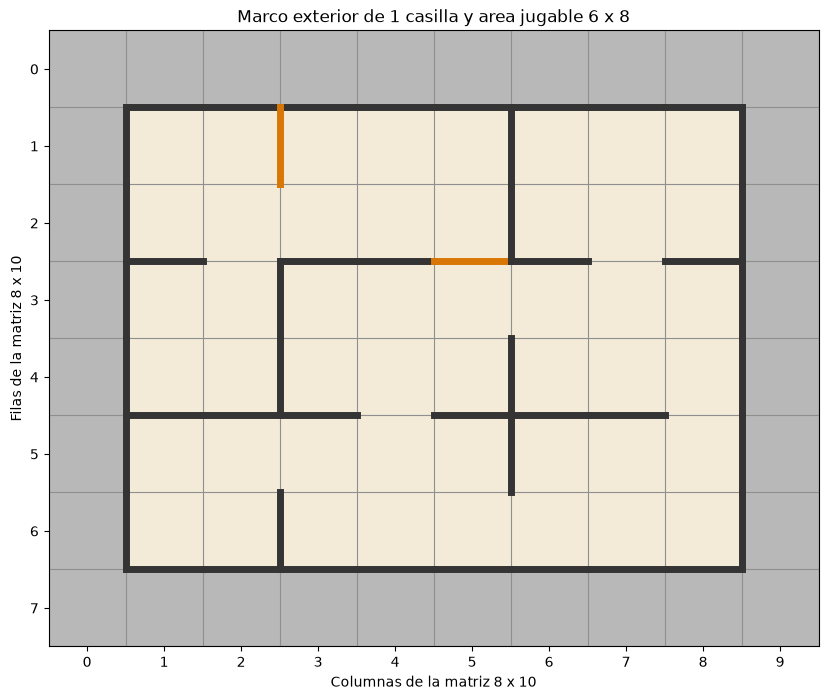

In [14]:
def dibujar_mapa(mapa, paredes_verticales, paredes_horizontales):
    figura, eje = plt.subplots(figsize=(10, 8))
    colores_mapa = ["#f3ead8"] * 10
    colores_mapa[MARCO] = "#b8b8b8"
    eje.imshow(mapa, cmap=ListedColormap(colores_mapa), vmin=0, vmax=9)

    # Las celdas de imshow estan centradas en enteros; las paredes van en sus bordes .5.
    for limite_fila in range(FILAS_JUGABLES + 1):
        for columna in range(COLUMNAS_JUGABLES):
            estado = paredes_horizontales[limite_fila, columna]
            x_inicio = columna + 0.5
            x_final = columna + 1.5
            y = limite_fila + 0.5
            if estado == PARED:
                eje.plot([x_inicio, x_final], [y, y], color="#343434", linewidth=5)
            elif estado == PUERTA_CERRADA:
                eje.plot([x_inicio, x_final], [y, y], color="#d97706", linewidth=5)
            elif estado == PUERTA_ABIERTA:
                eje.plot([x_inicio, x_final], [y, y], color="#16a34a", linewidth=3, linestyle="--")

    for fila in range(FILAS_JUGABLES):
        for limite_columna in range(COLUMNAS_JUGABLES + 1):
            estado = paredes_verticales[fila, limite_columna]
            x = limite_columna + 0.5
            y_inicio = fila + 0.5
            y_final = fila + 1.5
            if estado == PARED:
                eje.plot([x, x], [y_inicio, y_final], color="#343434", linewidth=5)
            elif estado == PUERTA_CERRADA:
                eje.plot([x, x], [y_inicio, y_final], color="#d97706", linewidth=5)
            elif estado == PUERTA_ABIERTA:
                eje.plot([x, x], [y_inicio, y_final], color="#16a34a", linewidth=3, linestyle="--")

    eje.set_xlim(-0.5, COLUMNAS_MAPA - 0.5)
    eje.set_ylim(FILAS_MAPA - 0.5, -0.5)
    eje.set_xticks(range(COLUMNAS_MAPA))
    eje.set_yticks(range(FILAS_MAPA))
    eje.set_xticks(np.arange(-0.5, COLUMNAS_MAPA, 1), minor=True)
    eje.set_yticks(np.arange(-0.5, FILAS_MAPA, 1), minor=True)
    eje.grid(False)
    eje.grid(which="minor", color="#8f8f8f", linewidth=0.8)
    eje.tick_params(which="minor", bottom=False, left=False)
    eje.set_xlabel("Columnas de la matriz 8 x 10")
    eje.set_ylabel("Filas de la matriz 8 x 10")
    eje.set_title("Marco exterior de 1 casilla y area jugable 6 x 8")
    plt.show()
    return figura, eje

figura_mapa, eje_mapa = dibujar_mapa(mapa, paredes_verticales, paredes_horizontales)

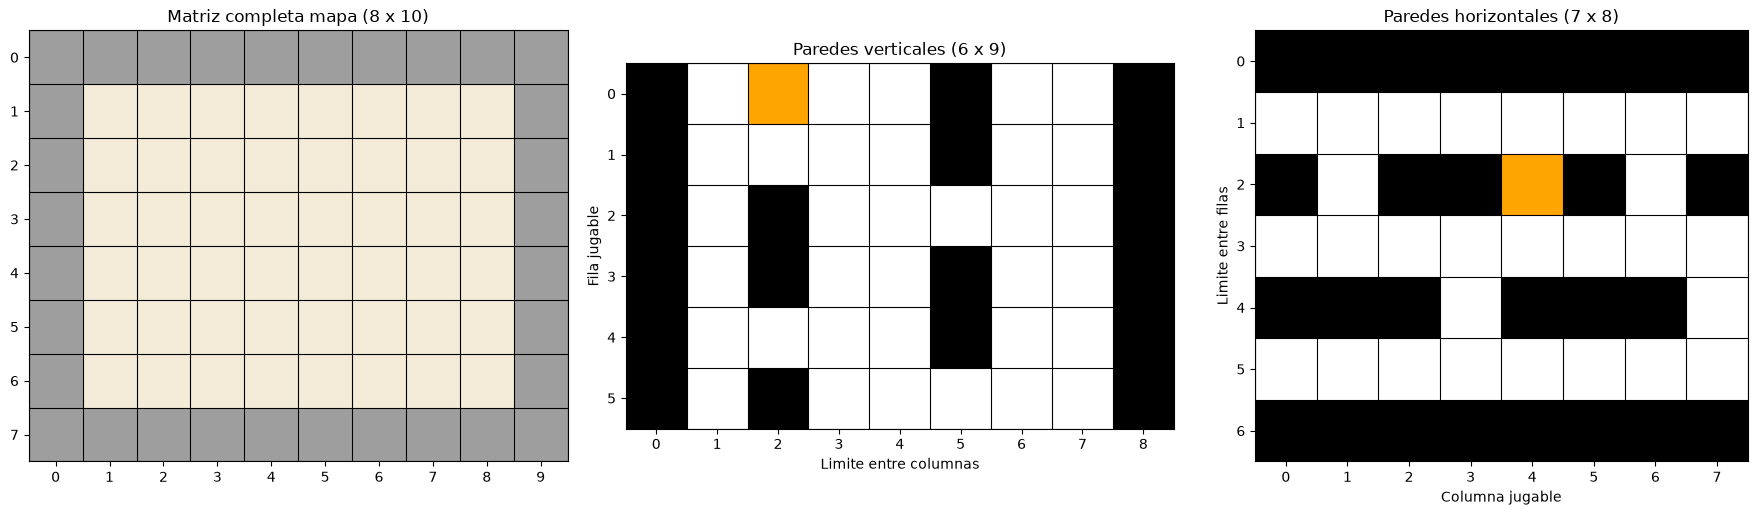

In [15]:
def mostrar_matrices(mapa, tablero, paredes_verticales, paredes_horizontales):
    figura, ejes = plt.subplots(1, 3, figsize=(18, 5))

    colores_mapa = ["#f3ead8"] * 10
    colores_mapa[MARCO] = "#9e9e9e"
    ejes[0].imshow(mapa, cmap=ListedColormap(colores_mapa), vmin=0, vmax=9)
    ejes[0].set_title("Matriz completa mapa (8 x 10)")
    ejes[0].set_xticks(range(COLUMNAS_MAPA))
    ejes[0].set_yticks(range(FILAS_MAPA))
    ejes[0].set_xticks(np.arange(-0.5, COLUMNAS_MAPA, 1), minor=True)
    ejes[0].set_yticks(np.arange(-0.5, FILAS_MAPA, 1), minor=True)
    ejes[0].grid(which="minor", color="black", linewidth=0.8)
    ejes[0].tick_params(which="minor", bottom=False, left=False)

    ejes[1].imshow(paredes_verticales, cmap=ListedColormap(["white", "black", "orange", "green"]), vmin=0, vmax=3)
    ejes[1].set_title("Paredes verticales (6 x 9)")
    ejes[1].set_xlabel("Limite entre columnas")
    ejes[1].set_ylabel("Fila jugable")
    ejes[1].set_xticks(range(COLUMNAS_JUGABLES + 1))
    ejes[1].set_yticks(range(FILAS_JUGABLES))
    ejes[1].set_xticks(np.arange(-0.5, COLUMNAS_JUGABLES + 1, 1), minor=True)
    ejes[1].set_yticks(np.arange(-0.5, FILAS_JUGABLES, 1), minor=True)
    ejes[1].grid(which="minor", color="black", linewidth=0.8)
    ejes[1].tick_params(which="minor", bottom=False, left=False)

    ejes[2].imshow(paredes_horizontales, cmap=ListedColormap(["white", "black", "orange", "green"]), vmin=0, vmax=3)
    ejes[2].set_title("Paredes horizontales (7 x 8)")
    ejes[2].set_xlabel("Columna jugable")
    ejes[2].set_ylabel("Limite entre filas")
    ejes[2].set_xticks(range(COLUMNAS_JUGABLES))
    ejes[2].set_yticks(range(FILAS_JUGABLES + 1))
    ejes[2].set_xticks(np.arange(-0.5, COLUMNAS_JUGABLES, 1), minor=True)
    ejes[2].set_yticks(np.arange(-0.5, FILAS_JUGABLES + 1, 1), minor=True)
    ejes[2].grid(which="minor", color="black", linewidth=0.8)
    ejes[2].tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.show()
    return figura, ejes

figura_matrices, ejes_matrices = mostrar_matrices(
    mapa, tablero, paredes_verticales, paredes_horizontales
)